# M3A3 - Transfer learning e Refinamento com Redes Pré-treinadas 

Na prática de hoje vamos refinar modelos de aprendizado profundo com [PyTorch](https://pytorch.org/).

Esse notebook está estruturado da seguinte forma.

- Introdução
- Carregar Base de Dados
- Refinar Modelo
- Próximos passos
- Atividade Complementares

## Introdução

Instalação para os que ainda não possuem a biblioteca instalada.

In [1]:
!pip install torch torchvision

Importar as bibliotecas e Ler Imagens do Disco

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import torch
import torchvision

## Carregar Base de Dados

A primeira tarefa para refinar um modelo é criar a base de dados.

In [ ]:
# Definir o pré-processamento dos dados.
# Resize para 64x64 — suficiente para MNIST, muito mais rápido que 224x224
transform = torchvision.transforms.Compose([torchvision.transforms.ToTensor(),
                                            torchvision.transforms.Resize(64)])

# Carregar o conjunto de treino.
train_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=True,         # Busca pelo sub conjunto de treino.
    download=True,      # Download do dados se necessário.
    transform=transform # Transformação a ser aplicada.
)

# Carregar o conjunto de teste.
test_data = torchvision.datasets.MNIST(
    root='./data',      # Pasta para salvar os dados.
    train=False,        # Busca pelo sub conjunto de teste.
    download=True,      # Download do dados se necessário.
    transform=transform # Transformação a ser aplicada.
)

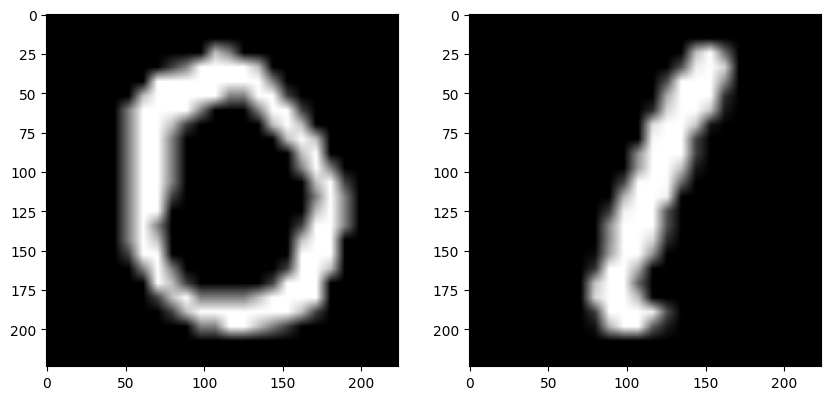

In [9]:
# Visualizar duas imagens aleatórias da base de dados.
indexes = [np.random.randint(0, len(train_data)), np.random.randint(0, len(train_data))]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(train_data[indexes[0]][0].numpy().transpose(1,2,0), cmap="gray")
axes[1].imshow(train_data[indexes[1]][0].numpy().transpose(1,2,0), cmap="gray")
plt.show()

## Refinar Modelo

Agora vamos carregar o modelo e refinar.

In [ ]:
# Carregar o modelo
vgg_16_model = torchvision.models.vgg16(weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)

# Vamos alterar a última camada.
num_classes = 10  # Número de classes na nova base.
in_features = vgg_16_model.classifier[6].in_features # Features que chegam na última camada.
vgg_16_model.classifier[6] = torch.nn.Linear(in_features, num_classes) # Substiu a última camada.

# Vamos alterar a primeira camada da rede para aceitar imagens em escala de cinza (1 canal).
new_first_conv = torch.nn.Conv2d(1, 64, kernel_size=3, padding=1)
vgg_16_model.features[0] = new_first_conv

# Ajustar o pooling adaptativo para compensar a entrada menor (64x64 em vez de 224x224)
vgg_16_model.avgpool = torch.nn.AdaptiveAvgPool2d((2, 2))
vgg_16_model.classifier[0] = torch.nn.Linear(512 * 2 * 2, 4096)

In [ ]:

# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Criar o dataloader para iterar nos dados.
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=1)

# Validar dispositivo de treino.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Colocar modelo no dispositivo.
vgg_16_model.to(device)

# Vamos medir a performance do modelo sem o refinamento.
correct = 0
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        target = target.to(device)
        output = vgg_16_model(data)
        preds = torch.argmax(torch.softmax(output, dim=1), dim=1)
        correct += (preds == target).sum().item()

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo sem refinamento: {acc * 100:.2f}%")

In [ ]:
########################
## Processo de treino. ##
########################

# Criando otimizador.
optimizer = torch.optim.SGD(vgg_16_model.parameters(), lr=0.0001)

# Definindo função de perda.
loss_criterion = torch.nn.CrossEntropyLoss()

# Usar subconjunto de 5000 amostras para treino mais rápido
train_subset = torch.utils.data.Subset(train_data, range(5000))

# Criar o dataloader de treino.
batch_size = 64  # Batch maior → gradiente mais estável e menos passos por época
train_loader = torch.utils.data.DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=4)

# Laço de treinamento.
epochs = 1
for epoch in range(epochs):
    # Colocar modelo em modo de treino.
    vgg_16_model.train()

    # Colocar modelo no dispositivo.
    vgg_16_model.to(device)
    
    # Função de perda e Acurácia para epóca.
    train_loss = 0.0
    train_acc = 0.0
    for batch_idx, (inputs, labels) in enumerate(train_loader):
        # Move os dados para o dispositivo de computação.
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Limpando os gradientes do otimizador.
        optimizer.zero_grad()

        # Passando informação no modelo.
        outputs = vgg_16_model(inputs)
        
        # Calculando a função de perda.
        loss = loss_criterion(outputs, labels)

        # Backpropagation dos gradientes.
        loss.backward()

        # Atualização dos parâmetros.
        optimizer.step()

        # Compute the total loss for the batch and add it to train_loss
        train_loss += loss.item() * inputs.size(0)
        
        # Calcule a acurácia.
        _, predictions = torch.max(outputs.data, 1)
        correct_counts = predictions.eq(labels.data.view_as(predictions))
        
        # Calcular a acurácia do batch.
        acc = torch.mean(correct_counts.type(torch.FloatTensor))
        
        # Calcular a acurácia total.
        train_acc += acc.item() * inputs.size(0)
        print("Batch number: {:03d}/{:03d}, Training: Loss: {:.4f}, Accuracy: {:.4f}".format(batch_idx, len(train_subset) // batch_size, loss.item(), acc.item()))


In [ ]:
# Vamos colocar o modelo em modo de avaliação.
vgg_16_model.eval()

# Criar o dataloader para iterar nos dados (batch maior = mais rápido).
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=1)

# Vamos medir a performance do modelo com refinamento.
correct = 0
with torch.no_grad():
    for batch_idx, (data, target) in enumerate(test_loader):
        data = data.to(device)
        target = target.to(device)
        output = vgg_16_model(data)
        preds = torch.argmax(torch.softmax(output, dim=1), dim=1)
        correct += (preds == target).sum().item()

# Calcula acurácia.
acc = correct/len(test_data)
print(f"Acurácia com modelo com refinamento: {acc * 100:.2f}%")

E com isso terminamos a prática de hoje.

## Próximos Passos e Referências

Nas próximas práticas vamos trasbalhar com problemas clássicos de Visão Computacional.

Uma lista não exaustiva de referências segue:

- https://pytorch.org/
- https://docs.pytorch.org/vision/main/models.html
- https://docs.pytorch.org/vision/0.8/datasets.html
- https://opencv.org/
- https://learnopencv.com/blogs/
- https://pyimagesearch.com/

## Atividades Complementares (Opicional)

- [x] Altere os hiperparâmetros, como número de epocas, tamanho do batch e learning rate do otimizador.
- [x] Tente utilizar outro modelo pré-treinado da mesma forma que utilizamos o modelo VGG 16.

### Atividade 1 — Alterando os hiperparâmetros

O loop de treino original usa `lr=0.0001`, `batch_size=16` e `epochs=1`. Abaixo mostro como ficaria com valores diferentes e o impacto de cada um. Para não travar o notebook, rodo só 30 batches pra ver a curva de loss.

In [ ]:
# Hiperparâmetros alternativos para experimentar
lr_novo = 0.001        # LR maior → convergência mais rápida, mas pode oscilar mais
batch_size_novo = 64   # Batch maior → gradiente mais estável, precisa de mais memória
epochs_novo = 3        # Mais épocas → mais treino (atenção ao overfitting)

optimizer_novo = torch.optim.SGD(vgg_16_model.parameters(), lr=lr_novo)
train_loader_novo = torch.utils.data.DataLoader(train_data, batch_size=batch_size_novo, shuffle=True, num_workers=4)

# Demonstração: treina por 30 batches para ver a curva de loss rapidamente
vgg_16_model.train()
losses_demo = []

for batch_idx, (inputs, labels) in enumerate(train_loader_novo):
    if batch_idx >= 30:
        break
    inputs, labels = inputs.to(device), labels.to(device)
    optimizer_novo.zero_grad()
    outputs = vgg_16_model(inputs)
    loss = loss_criterion(outputs, labels)
    loss.backward()
    optimizer_novo.step()
    losses_demo.append(loss.item())
    print(f"Batch {batch_idx+1:02d}/30 | Loss: {loss.item():.4f}")

plt.plot(losses_demo)
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.title(f"30 batches com lr={lr_novo}, batch_size={batch_size_novo}")
plt.show()

### Atividade 2 — Usando outro modelo: MobileNetV2

MobileNetV2 tem apenas 3.4M parâmetros (vs 138M do VGG-16), treinado também no ImageNet. Adaptações necessárias: primeira camada para 1 canal, última para 10 classes.

In [ ]:
mobilenet = torchvision.models.mobilenet_v2(weights=torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1)

# Adaptar a primeira camada para imagens em escala de cinza (MNIST tem 1 canal)
mobilenet.features[0][0] = torch.nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1, bias=False)

# Trocar a última camada para 10 classes (dígitos 0-9)
mobilenet.classifier[1] = torch.nn.Linear(mobilenet.last_channel, 10)

mobilenet.to(device)

# Baseline sem refinamento
mobilenet.eval()
test_loader_mobilenet = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=1)

correct = 0
n_samples = 500

with torch.no_grad():
    for i, (data, target) in enumerate(test_loader_mobilenet):
        if i * 64 >= n_samples:
            break
        data, target = data.to(device), target.to(device)
        output = mobilenet(data)
        preds = torch.argmax(torch.softmax(output, dim=1), dim=1)
        correct += (preds == target).sum().item()

actual_samples = min(n_samples, len(test_data))
print(f"MobileNetV2 sem refinamento (primeiras {actual_samples} amostras): {correct / actual_samples * 100:.2f}%")
print("Para refinar: rode o mesmo loop de treino trocando vgg_16_model por mobilenet.")